# Players Dataset: Predicting Player Macro Positions
This notebook predicts a player macro-position from selected player attributes and compares multiple tree-based classifiers.


In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from scipy.stats import randint, uniform, loguniform

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)
    print()
    print("Classification report:")
    print(classification_report(y_test, y_pred))
    print("Confusion matrix:")
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    print()

## Data Inspection
The player data is loaded, multi-position labels are simplified to the first listed position, and the target distribution is inspected before splitting the data.


/tmp/ipykernel_39889/331181806.py:1: DtypeWarning: Columns (203,205,206,207,217,218,221,222,233,234,236,237,239,240,244,245,247,262,279,286,287,291,292,294,296,298,299,300,301,304,305,306,311,312,366,379,394) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/players1.csv", sep=";", encoding='ISO-8859-1')


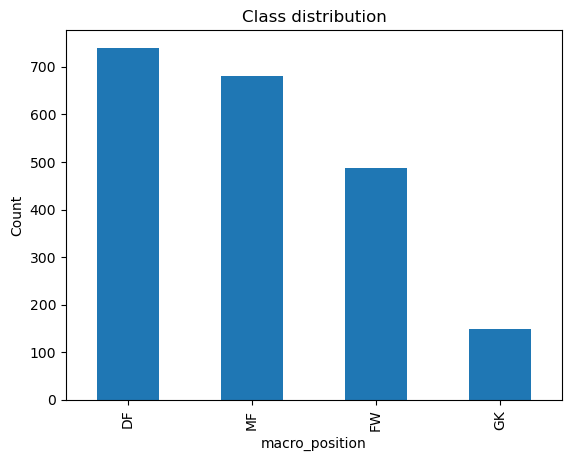

<class 'pandas.core.frame.DataFrame'>
Index: 2056 entries, 1246 to 1213
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   height                    2056 non-null   int64  
 1   minutes                   2056 non-null   int64  
 2   goals_per90               2056 non-null   float64
 3   assists_per90             2056 non-null   float64
 4   xg                        2056 non-null   float64
 5   npxg                      2056 non-null   float64
 6   xa                        2056 non-null   float64
 7   shots_total               2056 non-null   int64  
 8   shots_on_target           2056 non-null   int64  
 9   passes_completed          2056 non-null   int64  
 10  passes_pct                2056 non-null   float64
 11  passes_completed_long     2056 non-null   int64  
 12  progressive_passes        2056 non-null   int64  
 13  passes_into_final_third   2056 non-null   int64  
 14  passes_int

In [107]:
df = pd.read_csv("../data/players1.csv", sep=";", encoding='ISO-8859-1')
df["macro_position"] = df["position"].str.split(",").str[0]

'''
# detect useful features fro predict position
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    df.boxplot(column=col, by="macro_position")
    plt.title(f"{col} by position")
    plt.suptitle("")
    plt.xlabel("Position")
    plt.ylabel(col)
    plt.show()
'''

selected_cols = [
    # General
    "height",
    "minutes",

    # Offensive contribution
    "goals_per90",
    "assists_per90",
    "xg",
    "npxg",
    "xa",
    "shots_total",
    "shots_on_target",

    # Passing / playmaking
    "passes_completed",
    "passes_pct",
    "passes_completed_long",
    "progressive_passes",
    "passes_into_final_third",
    "passes_into_penalty_area",
    "passes_received",

    # Ball carrying / progression
    "carries",

    # Defensive actions
    "tackles",
    "dribble_tackles",
    "interceptions",
    "blocks",
    "clearances",

    # Pitch zones / touches
    "touches_def_3rd",
    "touches_mid_3rd",
    "touches_att_3rd",
    "touches_att_pen_area",

    # Other useful indicators
    "aerials_won",
    "cards_yellow"
]

X = df[selected_cols]
y = df["macro_position"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

y_train.value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

X_train.info()


## Preprocessing
Numerical player attributes are standardized and prepared through a column transformer.


In [108]:
num_pipeline = make_pipeline(
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, X_train.select_dtypes(include=["float64"]).columns),
])

## Model Comparison
Several tree-based models are trained and tuned so their classification performance can be compared on the same task.


### Decision Tree
A decision tree classifier is tuned by testing different pruning values for `ccp_alpha` with cross-validation.


/tmp/ipykernel_39889/508985458.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


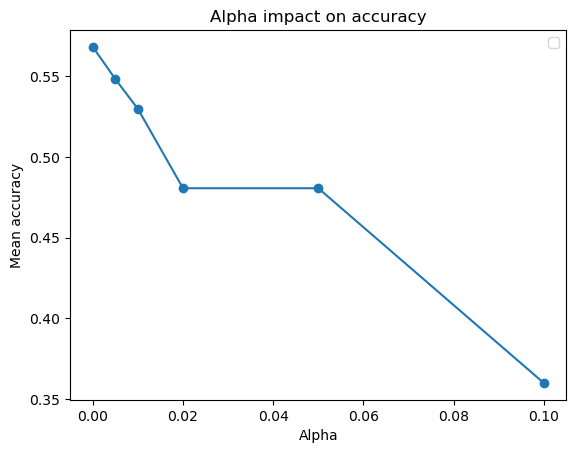

In [109]:
tree = make_pipeline(
    preprocessing,
    DecisionTreeClassifier(criterion="gini", max_depth=5)
)

alphas = [0, 0.005, 0.01, 0.02, 0.05, 0.1]

grid = GridSearchCV(
    tree,
    {"decisiontreeclassifier__ccp_alpha": alphas},
    refit=True,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

results = pd.DataFrame(grid.cv_results_)
alphas_mean_scores = results["mean_test_score"]

plt.plot(alphas, alphas_mean_scores, marker="o")
plt.xlabel("Alpha")
plt.ylabel("Mean accuracy")
plt.title("Alpha impact on accuracy")
plt.legend()



### Decision Tree Evaluation
The tuned decision tree is evaluated on the held-out test set with the shared evaluation helper.


Accuracy: 0.6019417475728155

Classification report:
              precision    recall  f1-score   support

          DF       0.59      0.86      0.70       185
          FW       0.72      0.57      0.64       122
          GK       0.49      0.46      0.47        37
          MF       0.57      0.37      0.45       171

    accuracy                           0.60       515
   macro avg       0.59      0.57      0.57       515
weighted avg       0.61      0.60      0.59       515

Confusion matrix:



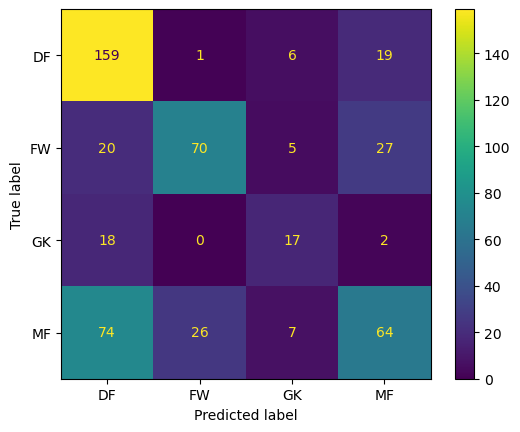

In [110]:
evaluate(best_model, X_test, y_test)

### Bagging
A bagging classifier is tuned by varying the number of base decision trees.


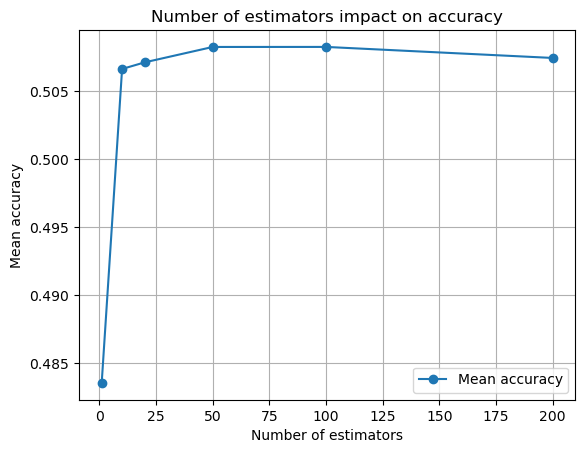

In [111]:
bagging = make_pipeline(
    preprocessing,
    BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42, max_depth=5),
        random_state=42,
        n_jobs=-1)
)

alphas = [0, 0.005, 0.01, 0.02, 0.05, 0.1]
n_estimators = [1, 10, 20, 50, 100, 200]

grid = GridSearchCV(
    bagging,
    {"baggingclassifier__estimator__ccp_alpha": alphas,
      "baggingclassifier__n_estimators": n_estimators
     },
    refit=True,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

results = pd.DataFrame(grid.cv_results_)
results = results.groupby(
    "param_baggingclassifier__n_estimators"
)["mean_test_score"].mean().reset_index()

plt.plot(
    results["param_baggingclassifier__n_estimators"],
    results["mean_test_score"],
    marker="o",
    label="Mean accuracy"
)

plt.xlabel("Number of estimators")
plt.ylabel("Mean accuracy")
plt.title("Number of estimators impact on accuracy")
plt.legend()
plt.grid(True)
plt.show()



### Bagging Evaluation
The selected bagging model is evaluated on the test set.


Accuracy: 0.6155339805825243

Classification report:
              precision    recall  f1-score   support

          DF       0.59      0.88      0.71       185
          FW       0.71      0.62      0.66       122
          GK       0.46      0.49      0.47        37
          MF       0.64      0.36      0.46       171

    accuracy                           0.62       515
   macro avg       0.60      0.59      0.58       515
weighted avg       0.63      0.62      0.60       515

Confusion matrix:



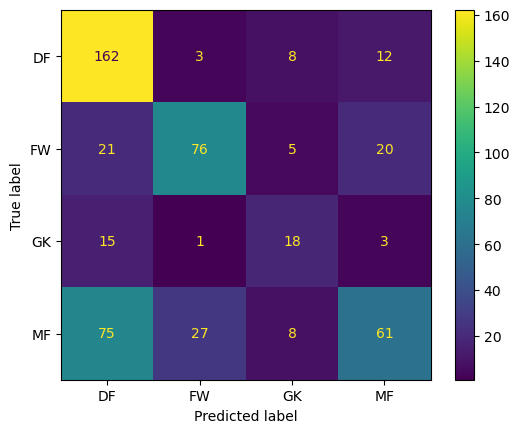

In [112]:
evaluate(grid.best_estimator_, X_test, y_test)

### Random Forest
A random forest classifier is tuned with randomized search over the main tree and ensemble hyperparameters.


In [115]:
forest = make_pipeline(
    preprocessing,
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1)
)

n_estimators = [1, 10, 20, 50, 100, 200]
max_depths = [4, 5, 6, 7]

grid = RandomizedSearchCV(
    forest,
    {
      "randomforestclassifier__n_estimators": n_estimators,
      "randomforestclassifier__ccp_alpha": alphas,
      "randomforestclassifier__max_depth": max_depths,
      "randomforestclassifier__criterion": ["gini", "entropy"]
     },
    refit=True,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

### Random Forest Evaluation
The selected random forest model is evaluated on the test set.


Accuracy: 0.6116504854368932

Classification report:
              precision    recall  f1-score   support

          DF       0.58      0.85      0.69       185
          FW       0.72      0.63      0.67       122
          GK       0.46      0.49      0.47        37
          MF       0.63      0.37      0.46       171

    accuracy                           0.61       515
   macro avg       0.60      0.58      0.58       515
weighted avg       0.62      0.61      0.60       515

Confusion matrix:



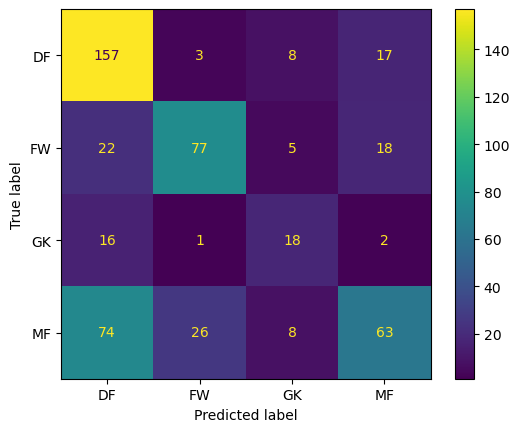

In [116]:
evaluate(grid.best_estimator_, X_test, y_test)

### Gradient Boosting
A gradient boosting classifier is tuned with randomized search over learning rate and related hyperparameters.


In [ ]:
forest = make_pipeline(
    preprocessing,
    GradientBoostingClassifier(
        random_state=42)
)

learning_rates = [0.01, 0.05, 0.1, 0.2]
grid = RandomizedSearchCV(
    forest,
    {
      "gradientboostingtclassifier__n_estimators": n_estimators,
      "gradientboostingclassifier__ccp_alpha": alphas,
      "gradientboostingclassifier__max_depth": max_depths,
      "gradientboostingclassifier__criterion": ["gini", "entropy"],
      "gradientboostingclassifier__learning_rate": learning_rates
     },
    refit=True,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

## Evaluation
The tuned models can be compared through the reported classification metrics to choose the most suitable classifier for player position prediction.
